# Tidal Prediction and Tide-Adjusted Nest Forcing

This tutorial demonstrates how to use `TideManager` to predict tides at target
locations and how to incorporate tidal adjustments when generating FVCOM nest forcing
files.

## Overview

FVCOM nest forcing files typically contain fields interpolated from a parent model
(e.g. CMEMS). These parent models often do not resolve tides, so a tidal signal must
be added separately. `TideManager` orchestrates this by:

1. Holding one `TPXOInterpolator` per variable (zeta, u, v).
2. Interpolating TPXO tidal harmonics onto arbitrary target positions.
3. Predicting tidal time series at those positions using UTide.

The tutorial is split into two parts:

- **Part 1** — Standalone tide prediction at a single location, to verify the
  setup and inspect the tidal signal.
- **Part 2** — Generating a tide-adjusted nest forcing file by combining CMEMS
  data with TPXO tidal predictions.

## Prerequisites

- PyFVCOM2 installed with all dependencies
- TPXO tidal harmonics files in NetCDF format (here we use TPXO10 Atlas v2)
- CMEMS oceanographic data files (for Part 2)
- FVCOM grid files (for Part 2)

## 1. Import Required Libraries

In [1]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# PyFVCOM2 imports
from pyfvcom2.tide_reader import TPXOComplexHarmonicsReader, get_tpxo_complex_harmonics_names
from pyfvcom2.interpolation import TPXOInterpolator
from pyfvcom2.tide import TideManager

/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## 2. Configuration

Define the tidal constituents to use and the paths to the TPXO data files.

In [2]:
# Tidal constituents
constituents = ['M2', 'S2', 'K1', 'O1']

# TPXO data directory
tpxo_data_dir = '/data/sthenno1/backup/jcl/data/TPXO/DATA/Atlas10v2'

# Build per-constituent file paths for elevation and transport
tpxo_h_files = {
    c: f'{tpxo_data_dir}/h_{c.lower()}_tpxo10_atlas_30_v2.nc'
    for c in constituents
}
tpxo_u_files = {
    c: f'{tpxo_data_dir}/u_{c.lower()}_tpxo10_atlas_30_v2.nc'
    for c in constituents
}
bathy_file = f'{tpxo_data_dir}/grid_tpxo10atlas_v2.nc'

print(f'Constituents: {constituents}')
print(f'Example elevation file: {tpxo_h_files["M2"]}')

Constituents: ['M2', 'S2', 'K1', 'O1']
Example elevation file: /data/sthenno1/backup/jcl/data/TPXO/DATA/Atlas10v2/h_m2_tpxo10_atlas_30_v2.nc


# Part 1 — Standalone Tide Prediction

We predict the tidal sea surface elevation at a single point (Plymouth Sound)
over a two-week period to verify the setup.

## 3. Read and Interpolate Elevation Harmonics

Load the TPXO elevation harmonics and create a `TPXOInterpolator`.
We use a bounding box centred on our target location to avoid loading the
entire global dataset.

In [3]:
# Target location: Plymouth Sound
target_lon = np.array([-4.15])
target_lat = np.array([50.35])

# Bounding box around the target (with generous margin for interpolation)
bbox = (target_lon[0] - 1, target_lon[0] + 1, target_lat[0] - 1, target_lat[0] + 1)

# Read elevation harmonics
h_reader = TPXOComplexHarmonicsReader(tpxo_h_files)
h_var_names = get_tpxo_complex_harmonics_names('zeta')
h_harmonics = h_reader.read_harmonics(
    constituents, h_var_names, fill_land=True, bbox=bbox, bbox_margin=0.1
)

# Create the interpolator
h_interpolator = TPXOInterpolator(h_harmonics)

print(f'Loaded {len(h_harmonics.constituents)} constituents: {h_harmonics.constituents}')
print(f'Amplitude shape: {np.asarray(h_harmonics.amplitudes).shape}')

Loaded 4 constituents: ['M2', 'S2', 'K1', 'O1']
Amplitude shape: (4, 66, 66)


## 4. Create TideManager and Predict Elevation

Create a `TideManager`, register the zeta interpolator, and predict the
tidal elevation over a 14-day period.

In [4]:
# Create TideManager
tide_manager = TideManager(constituents=constituents, pool_size=1)
tide_manager.add_interpolator('zeta', h_interpolator)

# Define prediction period (14 days at hourly intervals)
start = datetime(2026, 1, 1)
end = datetime(2026, 1, 31)
datetimes = np.array([
    start + timedelta(hours=i)
    for i in range(int((end - start).total_seconds() / 3600) + 1)
])

# Predict
zeta_prediction = tide_manager.predict('zeta', datetimes, target_lon, target_lat)

print(f'Prediction shape: {zeta_prediction.shape}  (n_times, n_points)')
print(f'Range: {zeta_prediction.min():.3f} to {zeta_prediction.max():.3f} m')

prep/calcs ... done.
Prediction shape: (721, 1)  (n_times, n_points)
Range: -2.284 to 2.348 m


## 5. Plot the Predicted Tidal Elevation

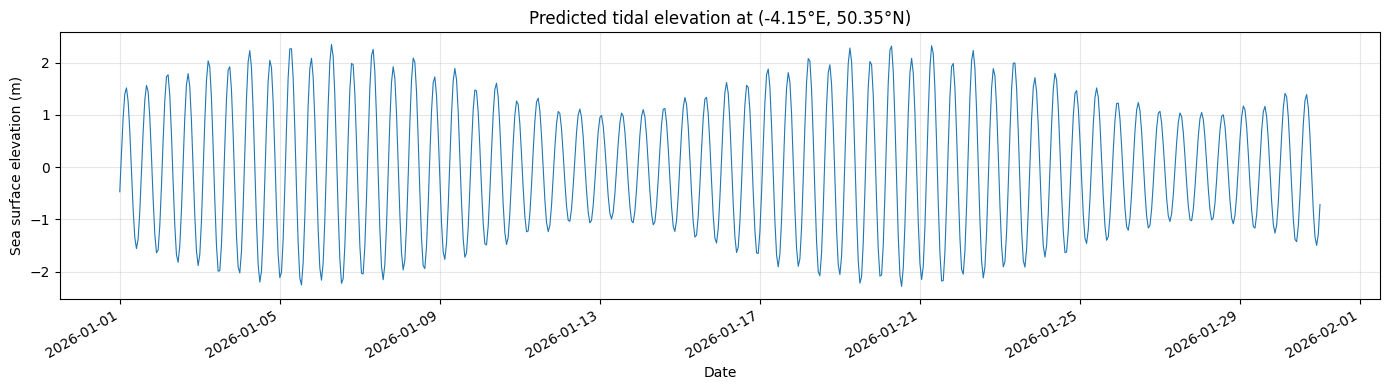

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(datetimes, zeta_prediction[:, 0], linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Sea surface elevation (m)')
ax.set_title(f'Predicted tidal elevation at ({target_lon[0]}°E, {target_lat[0]}°N)')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Part 2 — Tide-Adjusted Nest Forcing

We now demonstrate the full workflow: create a nest forcing file from CMEMS data
and add TPXO tidal predictions using `TideManager` and `NestManager`.

## 6. Additional Imports and Configuration

In [6]:
from pyfvcom2.file_utils import find_files
from pyfvcom2.date_utils import create_datetime_array
from pyfvcom2.grid import create_grid
from pyfvcom2.cmems_reader import CMEMSReader
from pyfvcom2.interpolation import CMEMSInterpolator
from pyfvcom2.nest import NestManager

# CMEMS data
cmems_data_dir = '/users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_reanalysis_7_km/Daily'

# FVCOM grid
home_dir = os.path.expanduser('~/code/git/pyfvcom2')
resources_dir = f'{home_dir}/resources'
grid_file = f'{resources_dir}/tamar_v2_grd.dat'
obc_file = f'{resources_dir}/tamar_v2_obc.dat'
sigma_file = f'{resources_dir}/sigma_gen.dat'

# Time period
start_date_time = datetime.strptime('20251214', '%Y%m%d')
end_date_time = datetime.strptime('20251215', '%Y%m%d')
date_times = create_datetime_array(start_date_time, end_date_time, timedelta(hours=1))

print(f'Time period: {start_date_time} to {end_date_time}')
print(f'Number of time steps: {len(date_times)}')

Time period: 2025-12-14 00:00:00 to 2025-12-15 00:00:00
Number of time steps: 25


## 7. Build the FVCOM Grid and NestManager

In [7]:
# Create FVCOM grid
fvcom_grid = create_grid(
    grid_file,
    mesh_type='fvcom',
    sigma_file=sigma_file,
    coordinate_system='cartesian',
    epsg_code='32630',
    obc_filename=obc_file,
)

# Create NestManager
nest_manager = NestManager(
    fvcom_grid,
    num_grid_bands=2,
    weights_calculation_method='linear',
)
nest_manager.set_dates(date_times)

print(f'Nodes: {fvcom_grid.n_nodes}, Elements: {fvcom_grid.n_elements}')
print(f'Nest nodes: {len(nest_manager.get_all_nest_nodes())}')
print(f'Nest elements: {len(nest_manager.get_all_nest_elements())}')

Updating NestManager dates and purging old forcing data for the previous dates.
Nodes: 39910, Elements: 75400
Nest nodes: 135
Nest elements: 173


## 8. Add CMEMS Forcing Data

Interpolate CMEMS oceanographic data onto the nest positions, just as in the
nest forcing tutorial.

In [8]:
# 2D data (sea surface height)
data_dir_2d = pathlib.Path(cmems_data_dir, '2D')
files_2d = find_files(data_dir_2d, 'cmems', start_date_time, end_date_time, tolerance_hours=1)
cmems_reader_2d = CMEMSReader(files_2d, reference_var_name='zos')
cmems_interpolator_2d = CMEMSInterpolator(cmems_reader_2d)
nest_manager.add_forcing_data(cmems_interpolator_2d, 'zeta', horizontal_position='node')

# 3D data (currents)
data_dir_3d = pathlib.Path(cmems_data_dir, '3D')
files_3d = find_files(data_dir_3d, 'cmems_mod_nws_phy-uv', start_date_time, end_date_time, tolerance_hours=1)
cmems_reader_3d = CMEMSReader(files_3d, reference_var_name='uo')
cmems_interpolator_3d = CMEMSInterpolator(cmems_reader_3d)

for fvcom_var, position in [('u', 'element'), ('v', 'element')]:
    nest_manager.add_forcing_data(cmems_interpolator_3d, fvcom_var, horizontal_position=position)

# 3D data (temp)
data_dir_3d = pathlib.Path(cmems_data_dir, '3D')
files_3d = find_files(data_dir_3d, 'cmems_mod_nws_phy-t', start_date_time, end_date_time, tolerance_hours=1)
cmems_reader_3d = CMEMSReader(files_3d, reference_var_name='thetao')
cmems_interpolator_3d = CMEMSInterpolator(cmems_reader_3d)

nest_manager.add_forcing_data(cmems_interpolator_3d, 'temp', horizontal_position='node')

# 3D data (salinity)
data_dir_3d = pathlib.Path(cmems_data_dir, '3D')
files_3d = find_files(data_dir_3d, 'cmems_mod_nws_phy-s', start_date_time, end_date_time, tolerance_hours=1)
cmems_reader_3d = CMEMSReader(files_3d, reference_var_name='so')
cmems_interpolator_3d = CMEMSInterpolator(cmems_reader_3d)

nest_manager.add_forcing_data(cmems_interpolator_3d, 'salinity', horizontal_position='node')

print('CMEMS forcing data added for: zeta, u, v, temperature and salinity')

Accessing CMEMS metadata from: /users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_reanalysis_7_km/Daily/2D/cmems_mod_nws_phy-ssh_my_7km-2D_P1D-m.nc
Depth dimension variable name depth not found in CMEMS file /users/modellers/jcl/data/pyfvcom2_doc/CMEMS_NWS_reanalysis_7_km/Daily/2D/cmems_mod_nws_phy-ssh_my_7km-2D_P1D-m.nc.
Assuming the dataset includes 2D variables only.
Using dimension variable names:
  Time: time
  Longitude: longitude
  Latitude: latitude
Using reference variable zos.
Interpolating CMEMS zos to FVCOM grid.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 00:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 01:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 02:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 03:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 04:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-14 05:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-12-1

## 9. Set Up TideManager with All Three Variables

Read TPXO harmonics for elevation (zeta), and both velocity components (u, v).
Create interpolators and register them with the `TideManager`.

We reuse the elevation interpolator from Part 1, but now read it with a bounding
box derived from the FVCOM domain, and add velocity interpolators.

In [9]:
# Bounding box from the FVCOM grid
bbox = (
    fvcom_grid.lon.min(), fvcom_grid.lon.max(),
    fvcom_grid.lat.min(), fvcom_grid.lat.max(),
)

# Elevation harmonics
h_reader = TPXOComplexHarmonicsReader(tpxo_h_files)
h_var_names = get_tpxo_complex_harmonics_names('zeta')
h_harmonics = h_reader.read_harmonics(constituents, h_var_names, fill_land=True, bbox=bbox, bbox_margin=0.1)
h_interpolator = TPXOInterpolator(h_harmonics)

# u-velocity harmonics
u_reader = TPXOComplexHarmonicsReader(tpxo_u_files)
u_var_names = get_tpxo_complex_harmonics_names('u')
u_harmonics = u_reader.read_harmonics(
    constituents, u_var_names, fill_land=True, bbox=bbox, bbox_margin=0.1, bathy_file=bathy_file
)
u_interpolator = TPXOInterpolator(u_harmonics)

# v-velocity harmonics
v_reader = TPXOComplexHarmonicsReader(tpxo_u_files)
v_var_names = get_tpxo_complex_harmonics_names('v')
v_harmonics = v_reader.read_harmonics(
    constituents, v_var_names, fill_land=True, bbox=bbox, bbox_margin=0.1, bathy_file=bathy_file
)
v_interpolator = TPXOInterpolator(v_harmonics)

# Create TideManager and register all three interpolators
tide_manager = TideManager(constituents=constituents)
tide_manager.add_interpolator('zeta', h_interpolator)
tide_manager.add_interpolator('u', u_interpolator)
tide_manager.add_interpolator('v', v_interpolator)

print('TideManager ready with interpolators for: zeta, u, v')

TideManager ready with interpolators for: zeta, u, v


## 10. Add Tidal Data to the NestManager

Call `add_tidal_data` which interpolates the harmonics onto all nest node and
element positions and predicts tidal time series at the dates previously set
via `set_dates`.

In [10]:
nest_manager.add_tidal_data(tide_manager)

print('Tidal predictions computed for all nest positions.')
print(f'  zeta shape: {nest_manager._tidal_data["zeta"].shape}')
print(f'  u shape:    {nest_manager._tidal_data["u"].shape}')
print(f'  v shape:    {nest_manager._tidal_data["v"].shape}')

prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... done.
done.prep/calcs ... done.
prep/calcs ... done.done.
prep/calcs ... 

done.done.prep/calcs ... done.done.
prep/calcs ... 
done.
prep/calcs ... prep/calcs ... done.

prep/calcs ... done.
done.prep/calcs ... 
prep/calcs ... 
prep/calcs ... done.done.done.prep/calcs ... prep/calcs ... done.


prep/calcs ... done.

prep/calcs ... done.prep/calcs ... done.prep/calcs ... done.done.

prep/calcs ... 

prep/calcs ... prep/calcs ... prep/calcs ... prep/calcs ... done.done.done.done.

done.
prep/calcs ... 
prep/calcs ... prep/calcs ... 
prep/calcs ... done.done.done.prep/calcs ... 

prep/calcs ... 
done.done.done.prep/calcs ... 
prep/calcs ... 
prep/calcs ... done.
done.
done.prep/calcs ... done.prep/calcs ... 
prep/calcs ... 

prep/calcs ... done.done.prep/calcs ... 
prep/calcs ... prep/calcs ... prep/calcs ... do

## 11. Write the Tide-Adjusted Nest Forcing File

When calling `create_forcing_file`, pass `adjust_tides` with the list of
variables that should have the tidal signal added. For 3D velocity variables
(u, v), the 2D barotropic tidal prediction is broadcast uniformly across all
depth levels.

In [11]:
output_file = 'tamar_v2_nest_forcing_with_tides.nc'

nest_manager.create_forcing_file(
    output_file,
    nest_type=3,
    adjust_tides=['zeta', 'u', 'v', 'ua', 'va'],
)

print(f'Nest forcing file with tidal adjustment created: {output_file}')
print(f'File size: {os.path.getsize(output_file) / (1024 * 1024):.1f} MB')

Nest forcing file with tidal adjustment created: tamar_v2_nest_forcing_with_tides.nc
File size: 2.0 MB


## 12. Quick Sanity Check

Compare the zeta time series at a chosen nest node with and without the tidal
adjustment to confirm the tidal signal has been added. Set `nest_index` to select
which nest node/element to examine.

Nest index: 70
Node location: lon=-4.0710, lat=49.8561
Element location: lon=-3.8417, lat=50.0976


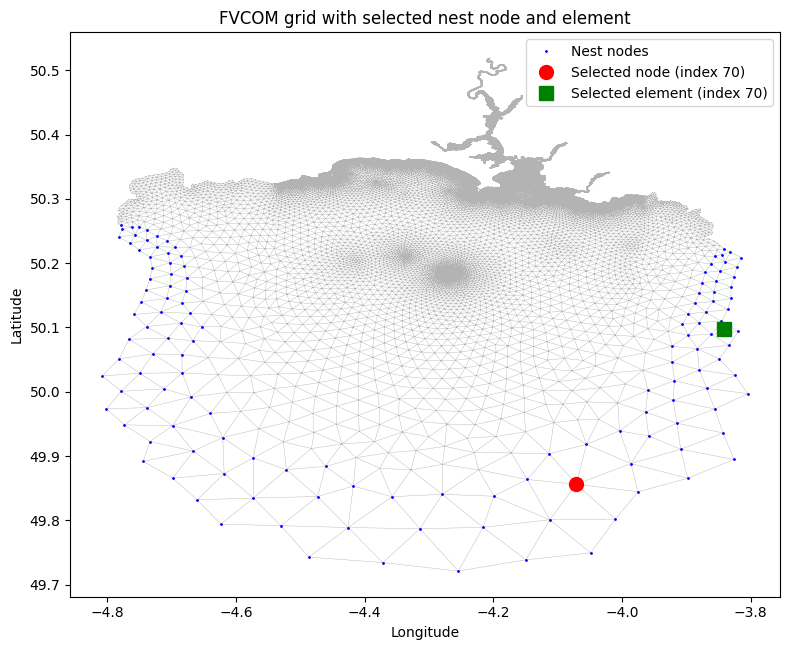

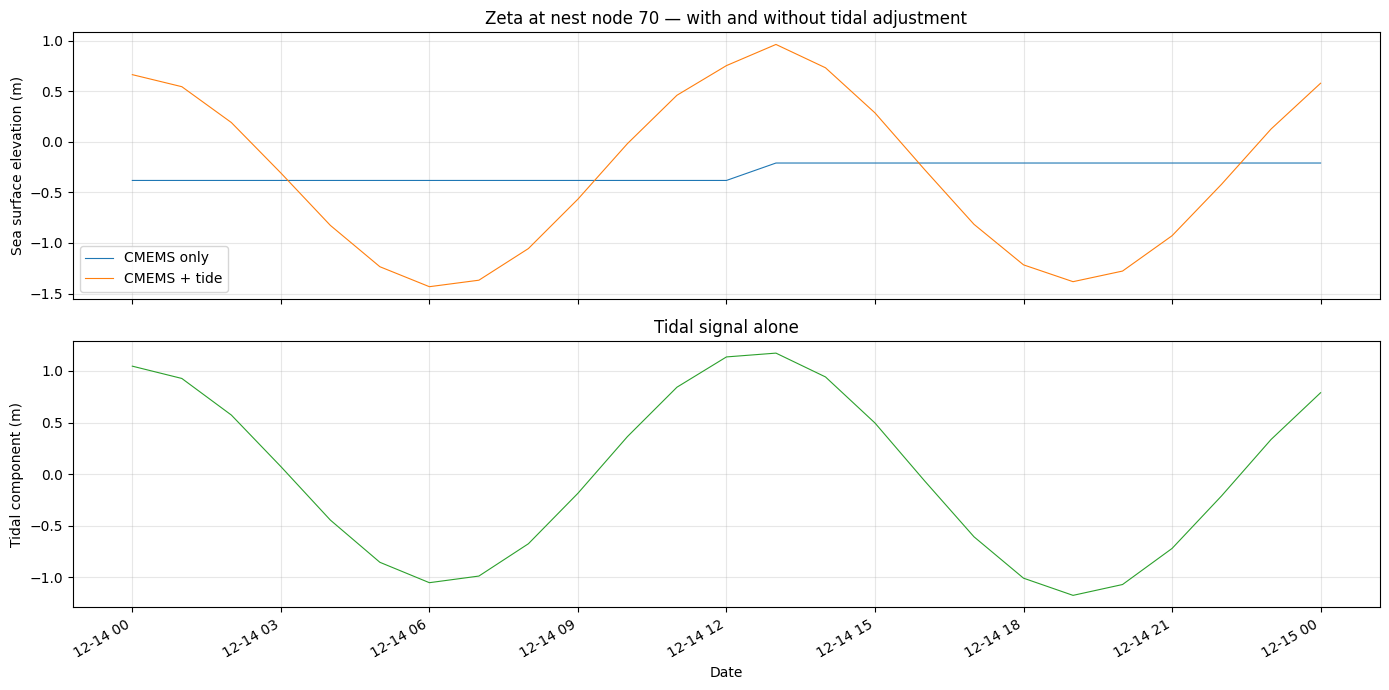

In [12]:
# --- Parameter: which nest node/element to plot ---
nest_index = 70

# Get node and element positions
nest_node_indices = nest_manager.get_all_nest_nodes()
nest_elem_indices = nest_manager.get_all_nest_elements()
node_lon = fvcom_grid.lon_nodes[nest_node_indices[nest_index]]
node_lat = fvcom_grid.lat_nodes[nest_node_indices[nest_index]]
elem_lon = fvcom_grid.lonc[nest_elem_indices[nest_index]]
elem_lat = fvcom_grid.latc[nest_elem_indices[nest_index]]
print(f'Nest index: {nest_index}')
print(f'Node location: lon={node_lon:.4f}, lat={node_lat:.4f}')
print(f'Element location: lon={elem_lon:.4f}, lat={elem_lat:.4f}')

# Plot geographic location
fig, ax = plt.subplots(figsize=(8, 8))
ax.triplot(fvcom_grid.lon_nodes, fvcom_grid.lat_nodes,
           fvcom_grid.triangles, linewidth=0.3, color='0.7')
ax.plot(fvcom_grid.lon_nodes[nest_node_indices],
        fvcom_grid.lat_nodes[nest_node_indices],
        'b.', markersize=2, label='Nest nodes')
ax.plot(node_lon, node_lat, 'ro', markersize=10, zorder=5,
        label=f'Selected node (index {nest_index})')
ax.plot(elem_lon, elem_lat, 'gs', markersize=10, zorder=5,
        label=f'Selected element (index {nest_index})')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('FVCOM grid with selected nest node and element')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Extract zeta time series at the selected node
zeta_cmems_only = nest_manager.get_forcing_data('zeta', adjust_tides=False)[:, nest_index]
zeta_adjusted = nest_manager.get_forcing_data('zeta', adjust_tides=True)[:, nest_index]
zeta_tidal = nest_manager.get_tidal_data('zeta')[:, nest_index]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(date_times, zeta_cmems_only, label='CMEMS only', linewidth=0.8)
axes[0].plot(date_times, zeta_adjusted, label='CMEMS + tide', linewidth=0.8)
axes[0].set_ylabel('Sea surface elevation (m)')
axes[0].legend()
axes[0].set_title(f'Zeta at nest node {nest_index} — with and without tidal adjustment')
axes[0].grid(True, alpha=0.3)

axes[1].plot(date_times, zeta_tidal, color='C2', linewidth=0.8)
axes[1].set_ylabel('Tidal component (m)')
axes[1].set_xlabel('Date')
axes[1].set_title('Tidal signal alone')
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 13. Compare with Hourly CMEMS Data

Load hourly CMEMS SSH and surface velocity data at two resolutions (7 km and
1.5 km) and compare with the daily CMEMS and tide-adjusted time series at the
selected nest node. We find the nearest CMEMS grid point to the nest node
location and extract the time series there.

In [13]:
import xarray as xr

# Use the node position defined by nest_index above
print(f'Nest node {nest_index}: lon={node_lon:.4f}, lat={node_lat:.4f}')

# --- 7 km hourly CMEMS data ---
hourly_data_dir_7km = os.path.expanduser('~/data/pyfvcom2_doc/CMEMS_NWS_reanalysis_7_km/Hourly/2D')

ds_ssh_7km = xr.open_dataset(os.path.join(hourly_data_dir_7km, 'cmems_mod_nws_phy-ssh_my_7km-2D_PT1H-i.nc'))
ds_uv_7km = xr.open_dataset(os.path.join(hourly_data_dir_7km, 'cmems_mod_nws_phy-uv_my_7km-2D_PT1H-i.nc'))

ssh_at_node_7km = ds_ssh_7km['zos'].sel(longitude=node_lon, latitude=node_lat, method='nearest')
hourly_ssh_7km = ssh_at_node_7km.sel(time=slice(start_date_time, end_date_time))
hourly_times_7km = hourly_ssh_7km.time.values

actual_lon_7km = float(ds_ssh_7km.longitude.sel(longitude=node_lon, method='nearest'))
actual_lat_7km = float(ds_ssh_7km.latitude.sel(latitude=node_lat, method='nearest'))
print(f'Nearest 7 km CMEMS grid point: lon={actual_lon_7km:.4f}, lat={actual_lat_7km:.4f}')
print(f'7 km hourly time steps in window: {len(hourly_times_7km)}')

# --- 1.5 km hourly CMEMS data ---
hourly_data_dir_1p5km = os.path.expanduser('~/data/pyfvcom2_doc/CMEMS_NWS_anfc_1.5_km/Hourly/2D')

ds_ssh_1p5km = xr.open_dataset(os.path.join(hourly_data_dir_1p5km, 'cmems_mod_nws_phy-ssh_anfc_1.5km-2D_PT1H-i.nc'))
ds_uv_1p5km = xr.open_dataset(os.path.join(hourly_data_dir_1p5km, 'cmems_mod_nws_phy-cur_anfc_1.5km-2D_PT1H-i.nc'))

ssh_at_node_1p5km = ds_ssh_1p5km['zos'].sel(longitude=node_lon, latitude=node_lat, method='nearest')
hourly_ssh_1p5km = ssh_at_node_1p5km.sel(time=slice(start_date_time, end_date_time))
hourly_times_1p5km = hourly_ssh_1p5km.time.values

actual_lon_1p5km = float(ds_ssh_1p5km.longitude.sel(longitude=node_lon, method='nearest'))
actual_lat_1p5km = float(ds_ssh_1p5km.latitude.sel(latitude=node_lat, method='nearest'))
print(f'Nearest 1.5 km CMEMS grid point: lon={actual_lon_1p5km:.4f}, lat={actual_lat_1p5km:.4f}')
print(f'1.5 km hourly time steps in window: {len(hourly_times_1p5km)}')

Nest node 70: lon=-4.0710, lat=49.8561
Nearest 7 km CMEMS grid point: lon=-4.1113, lat=49.8672
7 km hourly time steps in window: 25
Nearest 1.5 km CMEMS grid point: lon=-4.0606, lat=49.8513
1.5 km hourly time steps in window: 25


### Load Devonport Tide Gauge Data

Read the Devonport tide gauge observations for December 2025, trim to the
simulation period, and find the nest node closest to the gauge location.
The mean SSH is subtracted so the gauge anomaly can be compared directly
with the model SSH (which is relative to MSL).

In [14]:
# Devonport tide gauge location and data file
gauge_lon = -4.18525
gauge_lat = 50.36839
gauge_file = os.path.expanduser('~/data/TideGuage/Devonport/Dec2025/DEV2512.txt')

# Read the tide gauge data
gauge_dates = []
gauge_elevations = []
n_header_lines = 12

with open(gauge_file, 'r') as f:
    for _ in range(n_header_lines):
        next(f)
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        date_str = f'{parts[1]} {parts[2]}'
        gauge_dates.append(datetime.strptime(date_str, '%Y/%m/%d %H:%M:%S'))
        gauge_elevations.append(float(parts[3].rstrip('M')))

gauge_dates = np.array(gauge_dates)
gauge_elevations = np.array(gauge_elevations)

# Subtract the mean of the full time series
gauge_mean = np.mean(gauge_elevations)
gauge_anomaly = gauge_elevations - gauge_mean

# Trim to the simulation period
mask = (gauge_dates >= start_date_time) & (gauge_dates <= end_date_time)
gauge_dates_trim = gauge_dates[mask]
gauge_anomaly_trim = gauge_anomaly[mask]

# Find the nest node closest to the tide gauge
nest_node_lons = fvcom_grid.lon_nodes[nest_node_indices]
nest_node_lats = fvcom_grid.lat_nodes[nest_node_indices]
dist = np.sqrt((nest_node_lons - gauge_lon)**2 + (nest_node_lats - gauge_lat)**2)
gauge_nest_index = int(np.argmin(dist))
gauge_node_lon = nest_node_lons[gauge_nest_index]
gauge_node_lat = nest_node_lats[gauge_nest_index]

print(f'Tide gauge location: lon={gauge_lon:.5f}, lat={gauge_lat:.5f}')
print(f'Closest nest node (index {gauge_nest_index}): lon={gauge_node_lon:.5f}, lat={gauge_node_lat:.5f}')
print(f'Distance: {dist[gauge_nest_index]:.5f}°')
print(f'Gauge records in window: {mask.sum()} (of {len(gauge_dates)} total)')
print(f'Mean elevation subtracted: {gauge_mean:.3f} m')

# Extract model SSH at the closest nest node
zeta_cmems_gauge = nest_manager.get_forcing_data('zeta', adjust_tides=False)[:, gauge_nest_index]
zeta_adjusted_gauge = nest_manager.get_forcing_data('zeta', adjust_tides=True)[:, gauge_nest_index]
zeta_tidal_gauge = nest_manager.get_tidal_data('zeta')[:, gauge_nest_index]

Tide gauge location: lon=-4.18525, lat=50.36839
Closest nest node (index 130): lon=-3.87060, lat=50.18548
Distance: 0.36395°
Gauge records in window: 97 (of 2975 total)
Mean elevation subtracted: 3.644 m


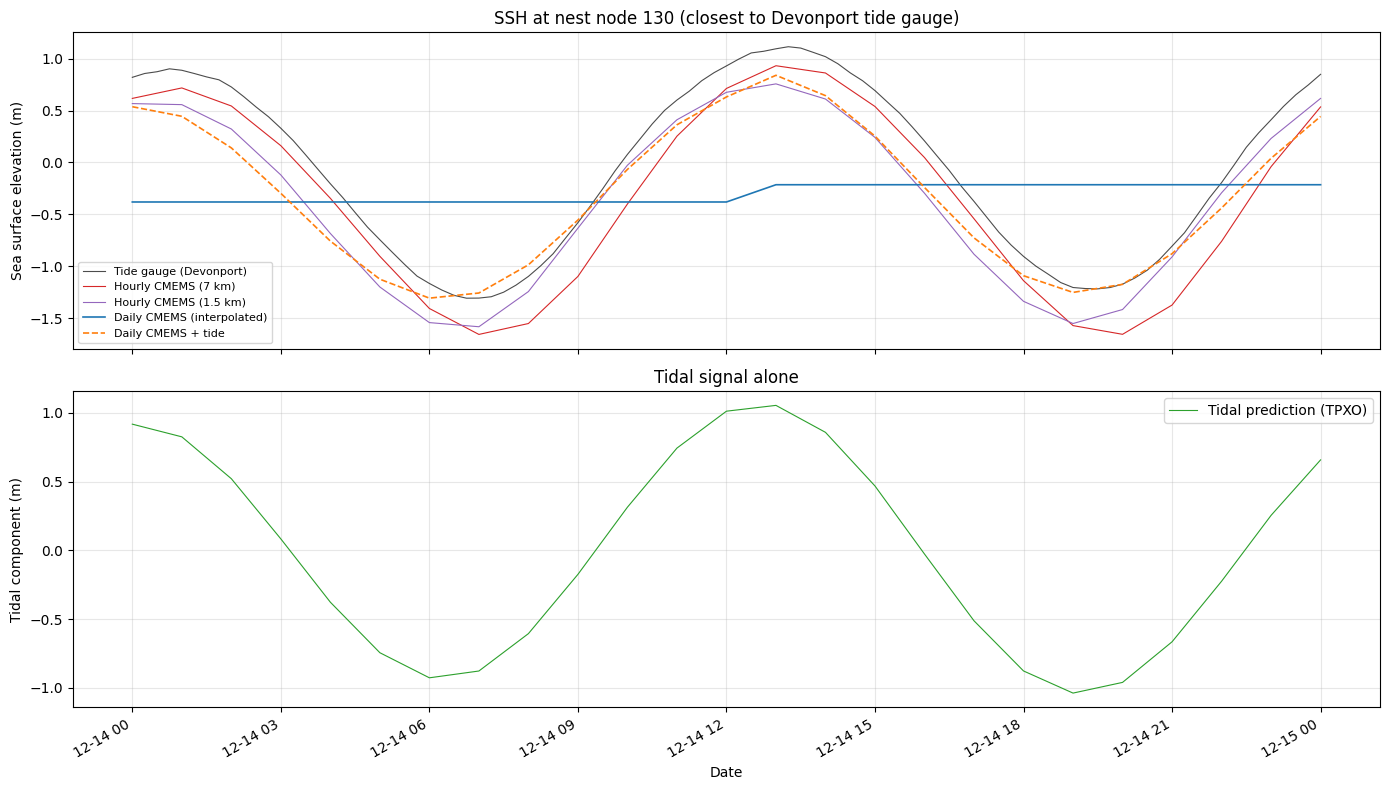

In [15]:
# SSH comparison — using the nest node closest to the Devonport tide gauge
# Extract hourly CMEMS SSH at the gauge nest node position
hourly_ssh_7km_gauge = ds_ssh_7km['zos'].sel(
    longitude=gauge_node_lon, latitude=gauge_node_lat, method='nearest'
).sel(time=slice(start_date_time, end_date_time))

hourly_ssh_1p5km_gauge = ds_ssh_1p5km['zos'].sel(
    longitude=gauge_node_lon, latitude=gauge_node_lat, method='nearest'
).sel(time=slice(start_date_time, end_date_time))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(gauge_dates_trim, gauge_anomaly_trim, label='Tide gauge (Devonport)',
             linewidth=0.8, color='k', alpha=0.7)
axes[0].plot(hourly_ssh_7km_gauge.time.values, hourly_ssh_7km_gauge.values,
             label='Hourly CMEMS (7 km)', linewidth=0.8, color='C3')
axes[0].plot(hourly_ssh_1p5km_gauge.time.values, hourly_ssh_1p5km_gauge.values,
             label='Hourly CMEMS (1.5 km)', linewidth=0.8, color='C4')
axes[0].plot(date_times, zeta_cmems_gauge, label='Daily CMEMS (interpolated)',
             linewidth=1.2, color='C0')
axes[0].plot(date_times, zeta_adjusted_gauge, label='Daily CMEMS + tide',
             linewidth=1.2, color='C1', linestyle='--')
axes[0].set_ylabel('Sea surface elevation (m)')
axes[0].legend(fontsize=8)
axes[0].set_title(f'SSH at nest node {gauge_nest_index} (closest to Devonport tide gauge)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(date_times, zeta_tidal_gauge, color='C2', linewidth=0.8, label='Tidal prediction (TPXO)')
axes[1].set_ylabel('Tidal component (m)')
axes[1].set_xlabel('Date')
axes[1].set_title('Tidal signal alone')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Surface Velocity Comparison

Compare surface u and v velocities from hourly CMEMS data with the tide-adjusted
nest forcing. The nest forcing velocities are extracted from the surface sigma layer
at the selected nest element (index controlled by `nest_index` above).

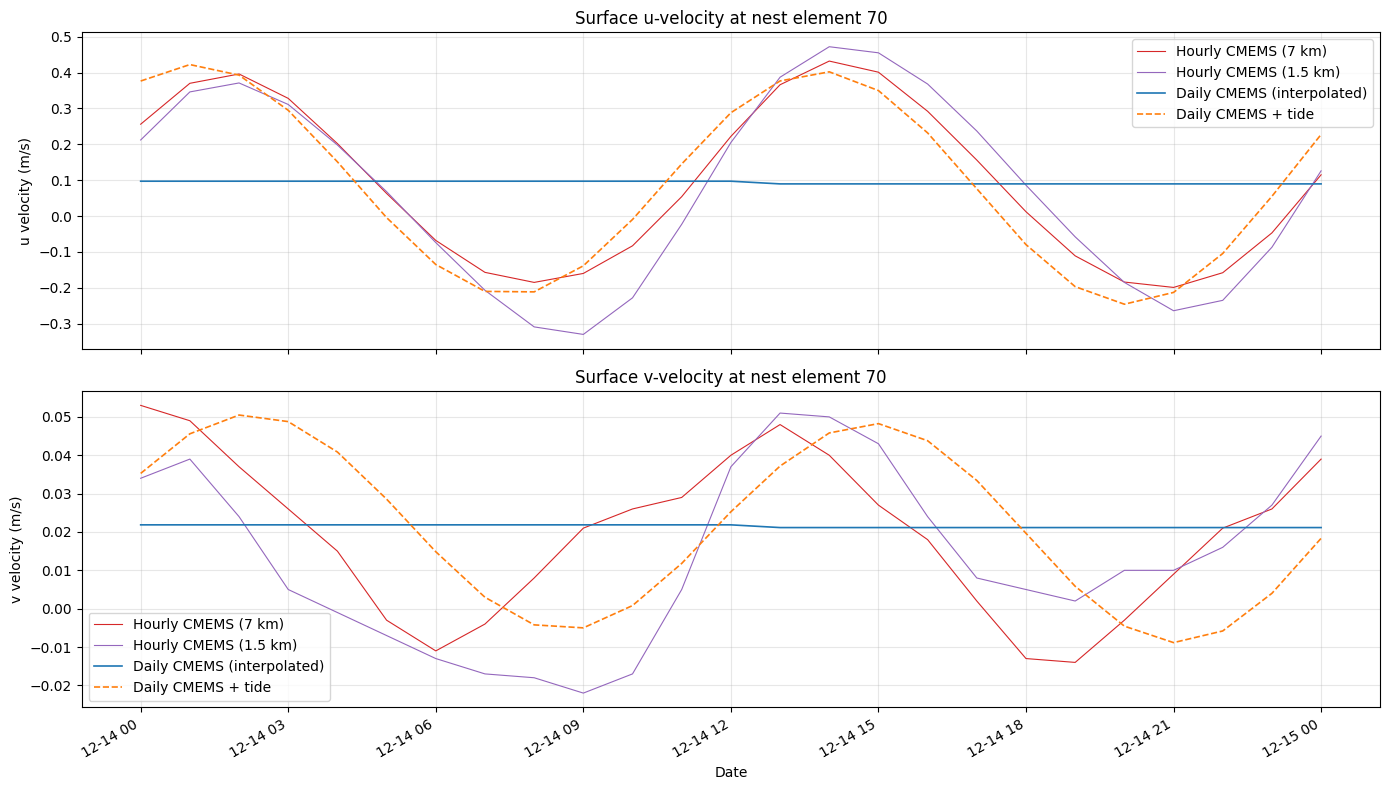

In [16]:
# Get nest forcing velocities at the selected element (surface layer = index 0)
u_cmems_only = nest_manager.get_forcing_data('u', adjust_tides=False)[:, 0, nest_index]
u_adjusted = nest_manager.get_forcing_data('u', adjust_tides=True)[:, 0, nest_index]
v_cmems_only = nest_manager.get_forcing_data('v', adjust_tides=False)[:, 0, nest_index]
v_adjusted = nest_manager.get_forcing_data('v', adjust_tides=True)[:, 0, nest_index]

# 7 km hourly velocities at the selected element position
hourly_uo_7km = ds_uv_7km['uo'].sel(longitude=elem_lon, latitude=elem_lat, method='nearest')
hourly_vo_7km = ds_uv_7km['vo'].sel(longitude=elem_lon, latitude=elem_lat, method='nearest')
hourly_uo_7km = hourly_uo_7km.sel(time=slice(start_date_time, end_date_time))
hourly_vo_7km = hourly_vo_7km.sel(time=slice(start_date_time, end_date_time))
hourly_uv_times_7km = hourly_uo_7km.time.values

# 1.5 km hourly velocities at the selected element position
hourly_uo_1p5km = ds_uv_1p5km['uo'].sel(longitude=elem_lon, latitude=elem_lat, method='nearest')
hourly_vo_1p5km = ds_uv_1p5km['vo'].sel(longitude=elem_lon, latitude=elem_lat, method='nearest')
hourly_uo_1p5km = hourly_uo_1p5km.sel(time=slice(start_date_time, end_date_time))
hourly_vo_1p5km = hourly_vo_1p5km.sel(time=slice(start_date_time, end_date_time))
hourly_uv_times_1p5km = hourly_uo_1p5km.time.values

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# u-velocity
axes[0].plot(hourly_uv_times_7km, hourly_uo_7km.values, label='Hourly CMEMS (7 km)', linewidth=0.8, color='C3')
axes[0].plot(hourly_uv_times_1p5km, hourly_uo_1p5km.values, label='Hourly CMEMS (1.5 km)', linewidth=0.8, color='C4')
axes[0].plot(date_times, u_cmems_only, label='Daily CMEMS (interpolated)', linewidth=1.2, color='C0')
axes[0].plot(date_times, u_adjusted, label='Daily CMEMS + tide', linewidth=1.2, color='C1', linestyle='--')
axes[0].set_ylabel('u velocity (m/s)')
axes[0].legend()
axes[0].set_title(f'Surface u-velocity at nest element {nest_index}')
axes[0].grid(True, alpha=0.3)

# v-velocity
axes[1].plot(hourly_uv_times_7km, hourly_vo_7km.values, label='Hourly CMEMS (7 km)', linewidth=0.8, color='C3')
axes[1].plot(hourly_uv_times_1p5km, hourly_vo_1p5km.values, label='Hourly CMEMS (1.5 km)', linewidth=0.8, color='C4')
axes[1].plot(date_times, v_cmems_only, label='Daily CMEMS (interpolated)', linewidth=1.2, color='C0')
axes[1].plot(date_times, v_adjusted, label='Daily CMEMS + tide', linewidth=1.2, color='C1', linestyle='--')
axes[1].set_ylabel('v velocity (m/s)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].set_title(f'Surface v-velocity at nest element {nest_index}')
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

ds_ssh_7km.close()
ds_uv_7km.close()
ds_ssh_1p5km.close()
ds_uv_1p5km.close()